# Monitoramento Inteligente de Áreas de Preservação Vegetal
## Classificação de Risco de Incêndio Florestal com Visão Computacional</h2>
  <hr style="border-color: #e94560; margin: 20px auto; width: 60%;"/>
  <table style="margin: 0 auto; color: #ccc; font-size: 0.95em; border-collapse: collapse;">
    <tr><td style="padding: 4px 16px; text-align: right; color: #a8dadc;"><b> Disciplina</b></td><td style="padding: 4px 16px;">Global Solution — Visão Computacional</td></tr>
    <tr><td style="padding: 4px 16px; text-align: right; color: #a8dadc;"><b> Dataset</b></td><td style="padding: 4px 16px;">Wildfire Prediction Dataset (Kaggle)</td></tr>
    <tr><td style="padding: 4px 16px; text-align: right; color: #a8dadc;"><b> Modelo</b></td><td style="padding: 4px 16px;">EfficientNetB0 + Transfer Learning</td></tr>
    <tr><td style="padding: 4px 16px; text-align: right; color: #a8dadc;"><b> Grupo</b></td><td style="padding: 4px 16px;">562800 - William Stahl Sanches Furquim Garcia &nbsp;|&nbsp; 566446 - Paulo Gabriel Pessoa da Silva</td></tr>



## 1. Contextualização do Problema Ambiental


O monitoramento de áreas de vegetação natural é uma atividade essencial para a preservação ambiental. Incêndios florestais representam uma das maiores ameaças à biodiversidade e ao equilíbrio climático do planeta. Segundo dados do **INPE**, o Brasil registrou **mais de 200.000 focos de incêndio em 2023**, evidenciando a urgência de sistemas inteligentes de detecção.


###  Objetivo do Projeto

Desenvolver um **classificador binário** capaz de identificar, a partir de imagens de satélite, se uma região apresenta:

-  **Wildfire** — área com ocorrência ou risco elevado de incêndio florestal
-  **No Wildfire** — área sem risco de incêndio

O modelo usa **Transfer Learning** com EfficientNetB0, uma das arquiteturas mais eficientes da atualidade para classificação de imagens.


##  2. Instalação e Configuração do Ambiente

**Pré-requisito:** Execute este notebook no Google Colab com **GPU T4** ativada.  
Vá em `Runtime > Change runtime type > T4 GPU`


In [1]:
# Instalar biblioteca do Kaggle para baixar o dataset
!pip install kaggle -q

# Verificar GPU disponível
import tensorflow as tf
print('TensorFlow versão:', tf.__version__)
print('GPU disponível:', tf.config.list_physical_devices('GPU'))


TensorFlow versão: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# =====================================================================
# CONFIGURAÇÃO DO KAGGLE API
# Faça upload do arquivo kaggle.json nesta célula
# (veja instruções no final do notebook)
# =====================================================================
from google.colab import files
print('Faça upload do arquivo kaggle.json:')
uploaded = files.upload()


Faça upload do arquivo kaggle.json:


Saving kaggle.json to kaggle.json


In [3]:
import os

# Mover kaggle.json para o diretório correto
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print('Kaggle API configurada com sucesso!')


Kaggle API configurada com sucesso!


In [4]:
# Baixar o dataset do Kaggle
!kaggle datasets download -d abdelghaniaaba/wildfire-prediction-dataset
print('Download concluído!')


Dataset URL: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset
License(s): other
100% 1.45G/1.45G [01:22<00:00, 18.9MB/s]

Download concluído!


In [5]:
# Descompactar o dataset
!unzip -q wildfire-prediction-dataset.zip -d wildfire_data
print('Descompactado com sucesso!')

# Verificar estrutura de pastas
!find wildfire_data -maxdepth 3 -type d | head -30


Descompactado com sucesso!
wildfire_data
wildfire_data/train
wildfire_data/train/wildfire
wildfire_data/train/nowildfire
wildfire_data/valid
wildfire_data/valid/wildfire
wildfire_data/valid/nowildfire
wildfire_data/test
wildfire_data/test/wildfire
wildfire_data/test/nowildfire


<a id="3"></a>
## 3. Importações e Configurações Globais

Abaixo importamos todas as bibliotecas necessárias e definimos os hiperparâmetros globais do projeto:

| Hiperparâmetro | Valor | Motivo |
|---|---|---|
| `IMG_SIZE` | `(224, 224)` | Dimensão padrão do EfficientNetB0 |
| `BATCH_SIZE` | `32 → 64` | Balanceia uso de memória GPU e velocidade |
| `EPOCHS_FT` | `5–10` | Fase 1: base congelada (aprendizado rápido) |
| `EPOCHS_UN` | `5–10` | Fase 2: fine-tuning (refinamento fino) |


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

# Configurações globais
IMG_SIZE   = (224, 224)   # EfficientNetB0 espera 224x224
BATCH_SIZE = 32
EPOCHS_FT  = 10           # Fine-tuning inicial (camadas congeladas)
EPOCHS_UN  = 10           # Unfreeze parcial

print(' Ambiente configurado com sucesso!')
print(f'   IMG_SIZE   = {IMG_SIZE}')
print(f'   BATCH_SIZE = {BATCH_SIZE}')
print(f'   EPOCHS_FT  = {EPOCHS_FT}')
print(f'   EPOCHS_UN  = {EPOCHS_UN}')


 Ambiente configurado com sucesso!
   IMG_SIZE   = (224, 224)
   BATCH_SIZE = 32
   EPOCHS_FT  = 10
   EPOCHS_UN  = 10


<a id="4"></a>
##  4. Análise Exploratória do Dataset (EDA)

O dataset **Wildfire Prediction Dataset** contém imagens de satélite de 350×350 px, organizadas em subpastas por classe.  
A estrutura esperada é: `train/`, `valid/` e `test/`, cada uma com subpastas `wildfire/` e `nowildfire/`.

### Estrutura do dataset

```
wildfire_data/
├── train/
│   ├── wildfire/      (15.750 imagens)
│   └── nowildfire/    (14.500 imagens)
├── valid/
│   ├── wildfire/      (3.480 imagens)
│   └── nowildfire/    (2.820 imagens)
└── test/
    ├── wildfire/      (3.480 imagens)
    └── nowildfire/    (2.820 imagens)
```


In [7]:
# ---------------------------------------------------------------
# Detectar automaticamente os caminhos do dataset
# ---------------------------------------------------------------
BASE_DIR = 'wildfire_data'

# Procurar pastas train/valid/test recursivamente
for root, dirs, files in os.walk(BASE_DIR):
    for d in dirs:
        if d.lower() in ['train', 'valid', 'test', 'training', 'validation', 'testing']:
            print(os.path.join(root, d))


wildfire_data/train
wildfire_data/valid
wildfire_data/test


In [8]:
# ---------------------------------------------------------------
# AJUSTE AQUI se os caminhos forem diferentes
# ---------------------------------------------------------------
# Percorre a estrutura para encontrar automaticamente
def find_split_dirs(base):
    result = {}
    for root, dirs, _ in os.walk(base):
        for d in dirs:
            dl = d.lower()
            if dl in ['train', 'training']:
                result['train'] = os.path.join(root, d)
            elif dl in ['valid', 'validation', 'val']:
                result['valid'] = os.path.join(root, d)
            elif dl in ['test', 'testing']:
                result['test'] = os.path.join(root, d)
    return result

splits = find_split_dirs(BASE_DIR)
TRAIN_DIR = splits.get('train')
VALID_DIR = splits.get('valid')
TEST_DIR  = splits.get('test')

print('Train:', TRAIN_DIR)
print('Valid:', VALID_DIR)
print('Test: ', TEST_DIR)


Train: wildfire_data/train
Valid: wildfire_data/valid
Test:  wildfire_data/test


In [9]:
# ---------------------------------------------------------------
# Contagem de imagens por classe e split
# ---------------------------------------------------------------
def count_images(split_dir):
    counts = {}
    if split_dir is None:
        return counts
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            n = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
            counts[cls] = n
    return counts

train_counts = count_images(TRAIN_DIR)
valid_counts = count_images(VALID_DIR)
test_counts  = count_images(TEST_DIR)

print('=== Distribuição do Dataset ===')
print(f'\nTreino:   {train_counts}')
print(f'Validação: {valid_counts}')
print(f'Teste:    {test_counts}')

total = sum(train_counts.values()) + sum(valid_counts.values()) + sum(test_counts.values())
print(f'\nTotal de imagens: {total}')


=== Distribuição do Dataset ===

Treino:   {'wildfire': 15750, 'nowildfire': 14500}
Validação: {'wildfire': 3480, 'nowildfire': 2820}
Teste:    {'wildfire': 3480, 'nowildfire': 2820}

Total de imagens: 42850


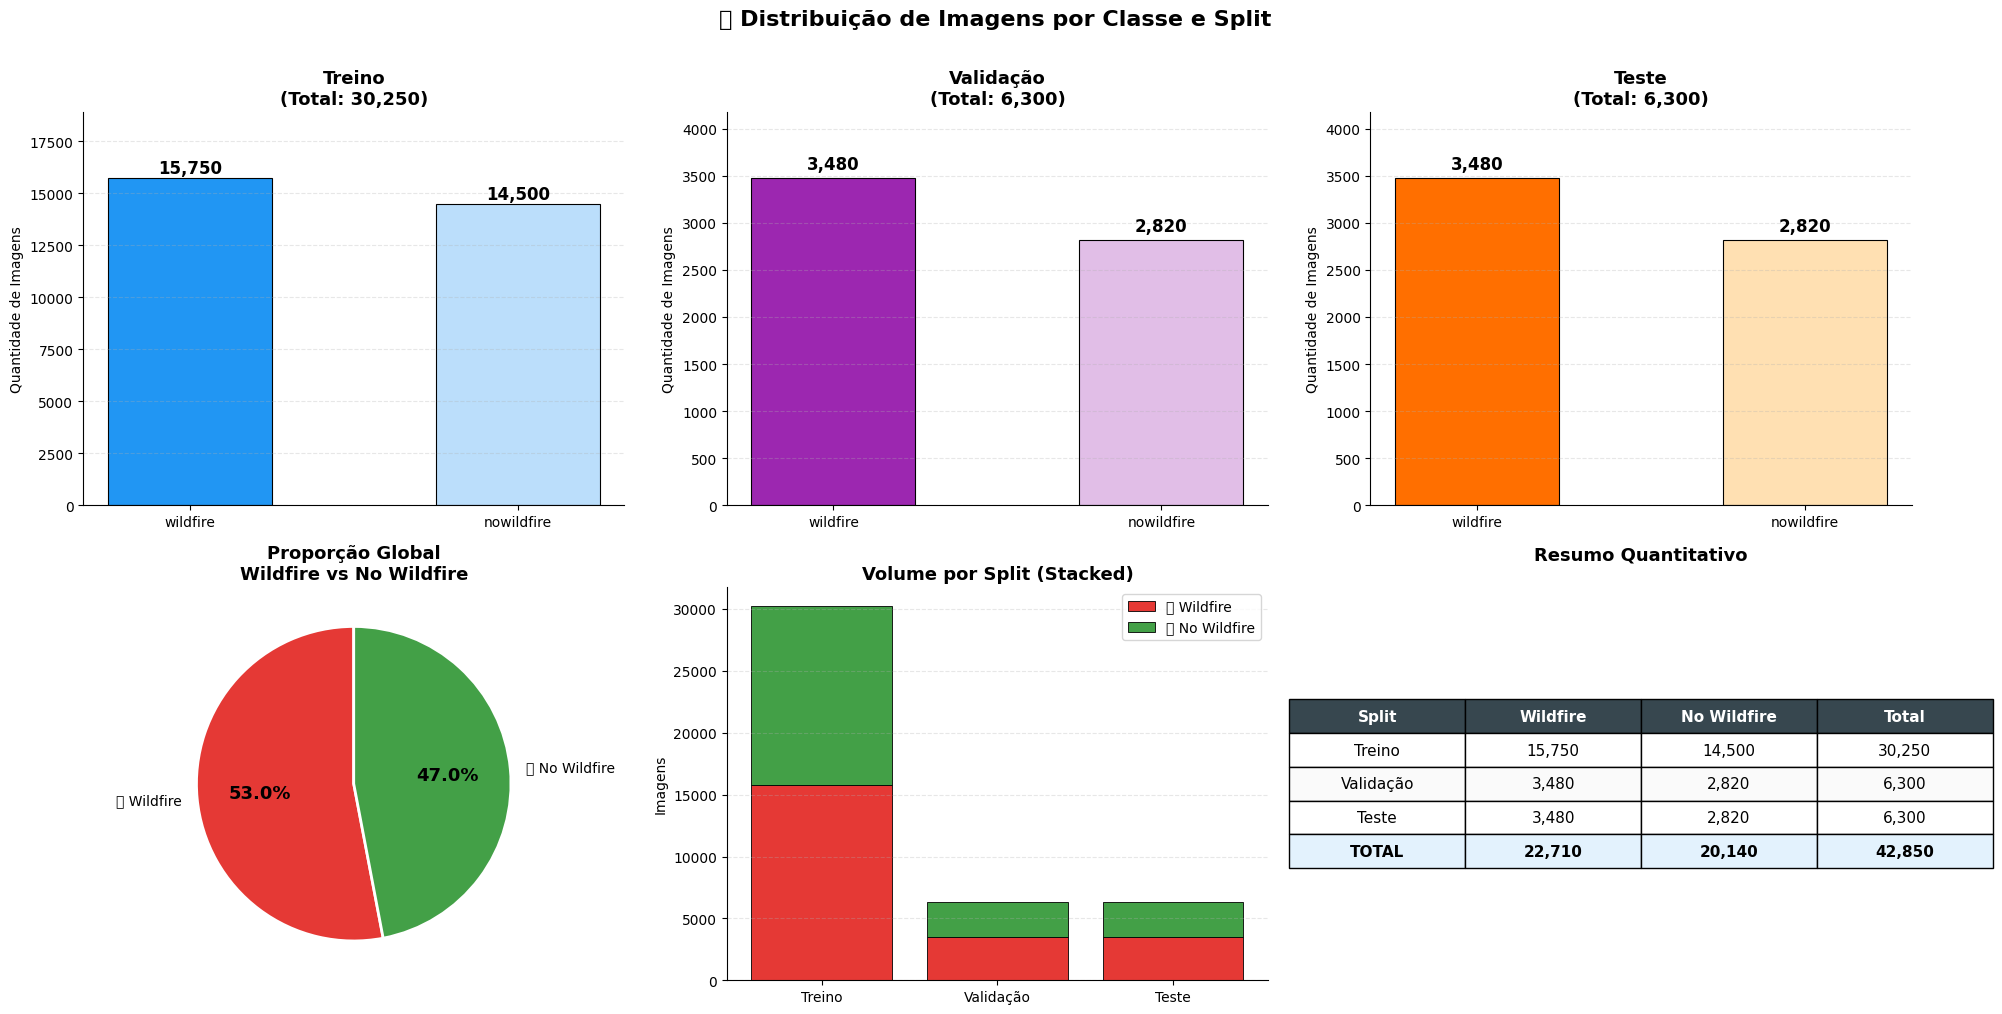

✅ Gráfico salvo!


In [10]:
# ---------------------------------------------------------------
# Gráfico de distribuição — barras + pizza lado a lado
# ---------------------------------------------------------------
fig = plt.figure(figsize=(20, 10))
fig.suptitle('📊 Distribuição de Imagens por Classe e Split', fontsize=16, fontweight='bold', y=1.01)

split_data = [
    ('Treino',    train_counts, '#2196F3', '#BBDEFB'),
    ('Validação', valid_counts, '#9C27B0', '#E1BEE7'),
    ('Teste',     test_counts,  '#FF6F00', '#FFE0B2'),
]

# Linha 1: barras por split
for idx, (title, counts, color_wf, color_nwf) in enumerate(split_data):
    ax = fig.add_subplot(2, 3, idx + 1)
    if counts:
        classes = list(counts.keys())
        values  = list(counts.values())
        bar_colors = [color_wf, color_nwf]
        bars = ax.bar(classes, values, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax.set_title(f'{title}\n(Total: {sum(values):,})', fontsize=13, fontweight='bold')
        ax.set_ylabel('Quantidade de Imagens')
        ax.set_ylim(0, max(values) * 1.2)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# Linha 2: gráfico de pizza — proporção global das classes
all_wildfire   = sum(c.get('wildfire', c.get('Wildfire', 0)) for c in [train_counts, valid_counts, test_counts])
all_nowildfire = sum(c.get('nowildfire', c.get('NoWildfire', c.get('no wildfire', 0))) for c in [train_counts, valid_counts, test_counts])

ax_pie = fig.add_subplot(2, 3, 4)
wedges, texts, autotexts = ax_pie.pie(
    [all_wildfire, all_nowildfire],
    labels=['🔥 Wildfire', '🌿 No Wildfire'],
    colors=['#e53935', '#43a047'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
ax_pie.set_title('Proporção Global\nWildfire vs No Wildfire', fontsize=13, fontweight='bold')

# Linha 2: stacked bar — comparativo entre splits
ax_stack = fig.add_subplot(2, 3, 5)
splits_names = ['Treino', 'Validação', 'Teste']
wf_vals  = [train_counts.get('wildfire', train_counts.get('Wildfire', 0)),
            valid_counts.get('wildfire', valid_counts.get('Wildfire', 0)),
            test_counts.get('wildfire',  test_counts.get('Wildfire', 0))]
nwf_vals = [sum(train_counts.values()) - wf_vals[0],
            sum(valid_counts.values()) - wf_vals[1],
            sum(test_counts.values())  - wf_vals[2]]
x = range(len(splits_names))
ax_stack.bar(x, wf_vals,  label='🔥 Wildfire',    color='#e53935', edgecolor='black', linewidth=0.6)
ax_stack.bar(x, nwf_vals, bottom=wf_vals, label='🌿 No Wildfire', color='#43a047', edgecolor='black', linewidth=0.6)
ax_stack.set_xticks(x)
ax_stack.set_xticklabels(splits_names)
ax_stack.set_title('Volume por Split (Stacked)', fontsize=13, fontweight='bold')
ax_stack.set_ylabel('Imagens')
ax_stack.legend()
ax_stack.grid(axis='y', alpha=0.3, linestyle='--')
ax_stack.spines['top'].set_visible(False)
ax_stack.spines['right'].set_visible(False)

# Linha 2: tabela resumo
ax_tab = fig.add_subplot(2, 3, 6)
ax_tab.axis('off')
table_data = [
    ['Split', 'Wildfire', 'No Wildfire', 'Total'],
    ['Treino',    f'{wf_vals[0]:,}',  f'{nwf_vals[0]:,}', f'{wf_vals[0]+nwf_vals[0]:,}'],
    ['Validação', f'{wf_vals[1]:,}',  f'{nwf_vals[1]:,}', f'{wf_vals[1]+nwf_vals[1]:,}'],
    ['Teste',     f'{wf_vals[2]:,}',  f'{nwf_vals[2]:,}', f'{wf_vals[2]+nwf_vals[2]:,}'],
    ['TOTAL',     f'{sum(wf_vals):,}', f'{sum(nwf_vals):,}', f'{sum(wf_vals)+sum(nwf_vals):,}'],
]
table = ax_tab.table(cellText=table_data[1:], colLabels=table_data[0],
                     loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == len(table_data) - 1:
        cell.set_facecolor('#E3F2FD')
        cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('#FAFAFA' if row % 2 == 0 else 'white')
ax_tab.set_title('Resumo Quantitativo', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo!')


In [11]:
# ---------------------------------------------------------------
# Visualização de exemplos — Wildfire vs No Wildfire
# ---------------------------------------------------------------
from PIL import Image
import random

def get_sample_images(split_dir, cls, n=5):
    cls_path = os.path.join(split_dir, cls)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    return [os.path.join(cls_path, f) for f in random.sample(imgs, min(n, len(imgs)))]

# Detectar nomes das classes
classes = sorted(os.listdir(TRAIN_DIR))
print('Classes encontradas:', classes)

# Mapear para Wildfire / No Wildfire
wildfire_cls   = [c for c in classes if 'wildfire' in c.lower() and 'no' not in c.lower()]
nowildfire_cls = [c for c in classes if 'no' in c.lower() or c.lower() == 'nowildfire']

if not wildfire_cls:
    wildfire_cls   = [classes[0]]
    nowildfire_cls = [classes[1]]

print('Wildfire class:   ', wildfire_cls[0])
print('NoWildfire class: ', nowildfire_cls[0])


Classes encontradas: ['nowildfire', 'wildfire']
Wildfire class:    wildfire
NoWildfire class:  nowildfire


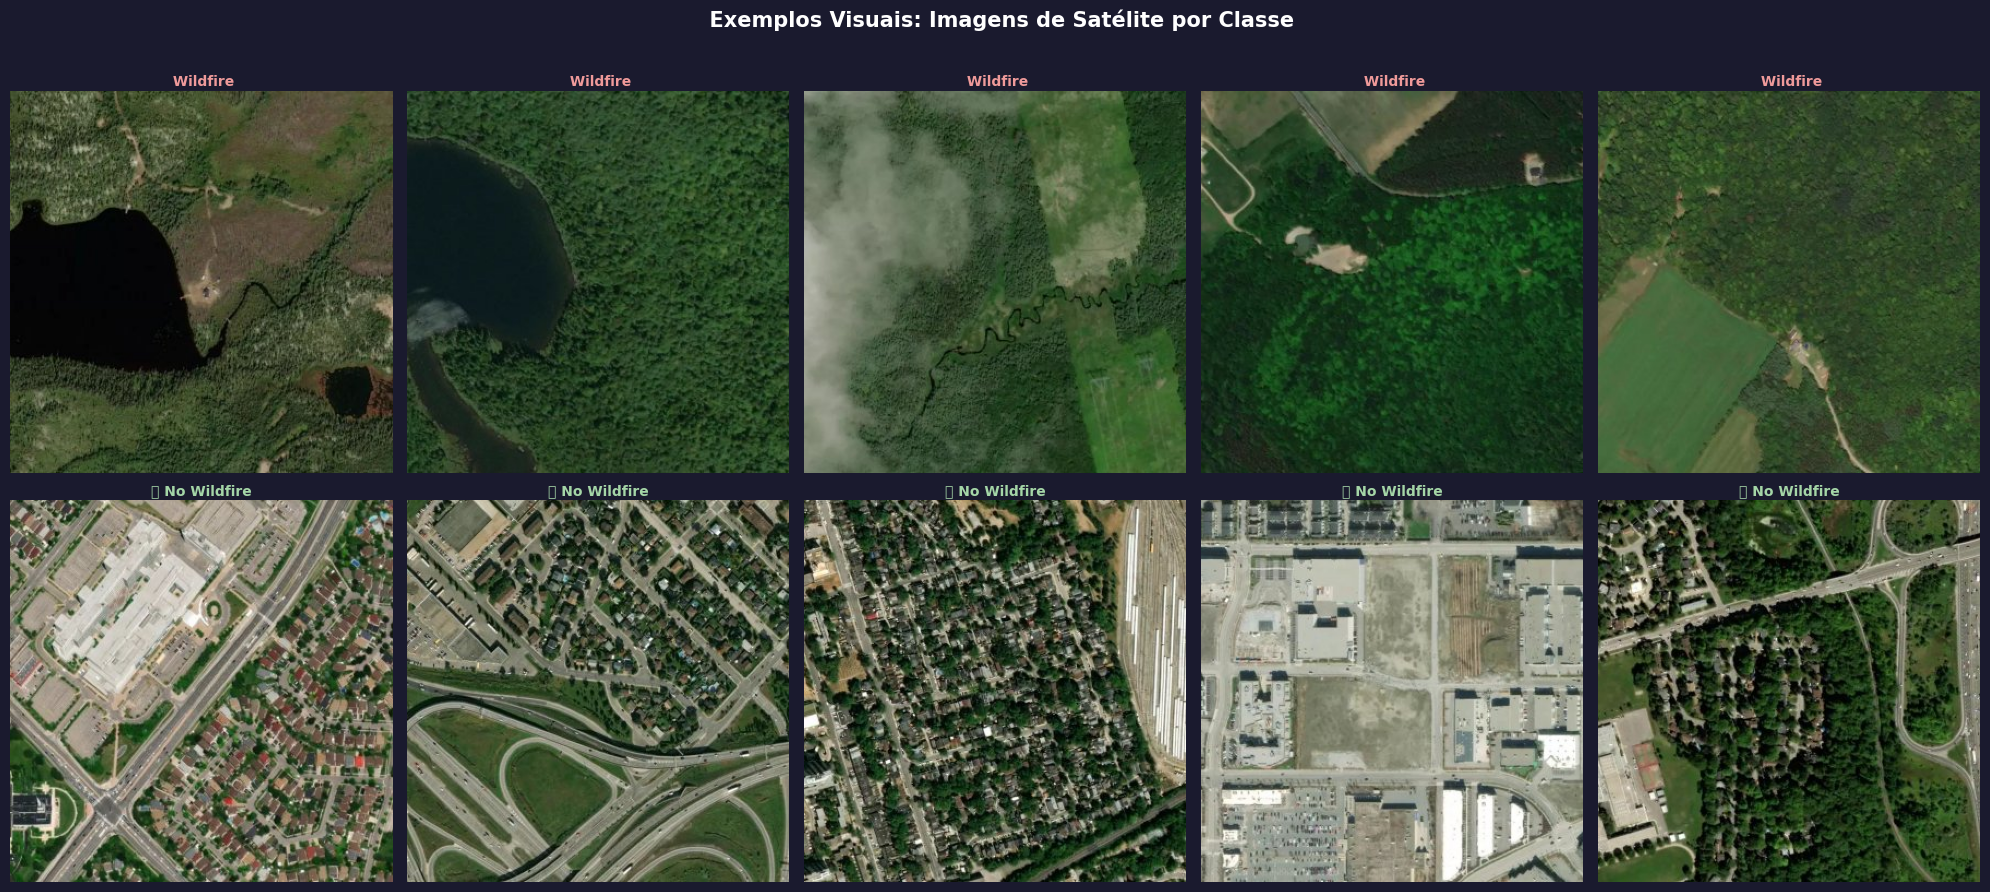

In [33]:
# ---------------------------------------------------------------
# Grade visual de exemplos com estilo aprimorado
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('  Exemplos Visuais: Imagens de Satélite por Classe',
             fontsize=15, fontweight='bold', color='white', y=1.01)

wf_imgs  = get_sample_images(TRAIN_DIR, wildfire_cls[0],   5)
nwf_imgs = get_sample_images(TRAIN_DIR, nowildfire_cls[0], 5)

for col, img_path in enumerate(wf_imgs):
    img = Image.open(img_path)
    axes[0, col].imshow(img)
    axes[0, col].axis('off')
    for spine in axes[0, col].spines.values():
        spine.set_edgecolor('#e53935')
        spine.set_linewidth(3)
    axes[0, col].set_title(f' Wildfire', color='#ef9a9a', fontsize=10, fontweight='bold', pad=4)

for col, img_path in enumerate(nwf_imgs):
    img = Image.open(img_path)
    axes[1, col].imshow(img)
    axes[1, col].axis('off')
    axes[1, col].set_title('🌿 No Wildfire', color='#a5d6a7', fontsize=10, fontweight='bold', pad=4)


plt.tight_layout()
plt.savefig('exemplos_visuais.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# ---------------------------------------------------------------
# Verificar dimensões das imagens
# ---------------------------------------------------------------
sample_path = wf_imgs[0]
img_sample  = Image.open(sample_path)
print(f' Dimensão original : {img_sample.size} px')
print(f' Modo de cor       : {img_sample.mode}')
print(f' Será redimensionado para: {IMG_SIZE} antes de entrar no modelo')


 Dimensão original : (350, 350) px
 Modo de cor       : RGB
 Será redimensionado para: (224, 224) antes de entrar no modelo


##  5. Pré-processamento e Preparação dos Dados

O pré-processamento é essencial para garantir que o modelo receba dados padronizados e que aprenda de forma robusta. As etapas incluem:

| Etapa | Conjunto | Descrição |
|---|---|---|
| **Redimensionamento** | Treino / Val / Teste | Todas as imagens → 224×224 px (padrão EfficientNetB0) |
| **Normalização** | Treino / Val / Teste | Pixels divididos por 255 → intervalo `[0, 1]` |
| **Data Augmentation** | Apenas Treino | Rotações, flips, zoom, shift, brilho — aumenta diversidade artificial |
| **Sem Augmentation** | Val e Teste | Garante avaliação justa e sem viés |

>  **Data Leakage Prevention:** O conjunto de **teste é reservado exclusivamente** para avaliação final. Nenhum dado de teste é visto durante o treinamento.


In [14]:
# ---------------------------------------------------------------
# Geradores de imagem com Data Augmentation
# ---------------------------------------------------------------

# Treino: augmentation + normalização
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

# Validação e Teste: apenas normalização (sem augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Geradores
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

valid_gen = val_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print('\nMapeamento de classes:', train_gen.class_indices)
print('Batches de treino:', len(train_gen))
print('Batches de validação:', len(valid_gen))
print('Batches de teste:', len(test_gen))


Found 30250 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.

Mapeamento de classes: {'nowildfire': 0, 'wildfire': 1}
Batches de treino: 946
Batches de validação: 197
Batches de teste: 197


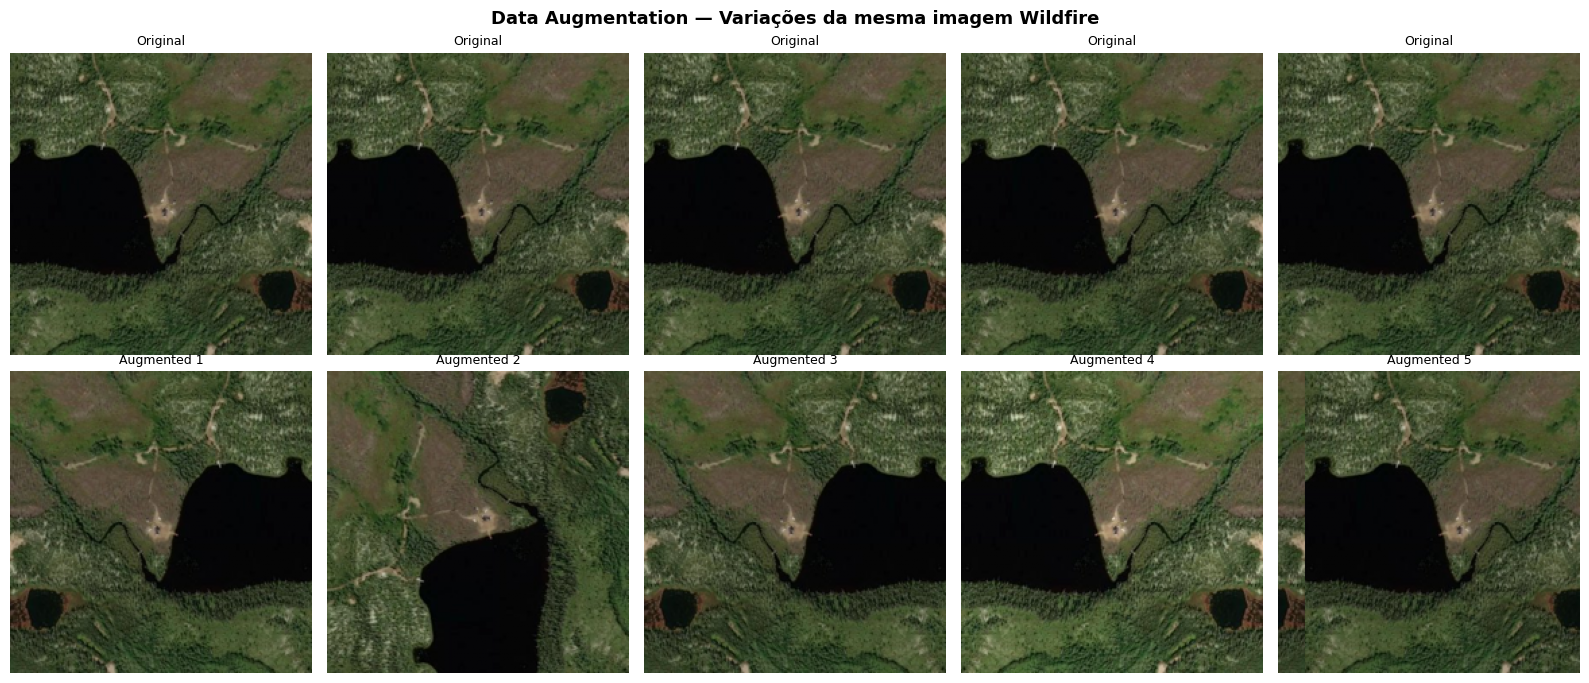

As augmentações aumentam a diversidade artificial do conjunto de treino
sem alterar os dados de validação e teste.


In [34]:
# ---------------------------------------------------------------
# Visualização do Data Augmentation
# ---------------------------------------------------------------
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_orig = Image.open(wf_imgs[0]).resize(IMG_SIZE)
img_array = np.array(img_orig) / 255.0

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Data Augmentation — Variações da mesma imagem Wildfire', fontsize=13, fontweight='bold')

for i in range(5):
    axes[0, i].imshow(img_array)
    axes[0, i].axis('off')
    axes[0, i].set_title('Original', fontsize=9)

# Augmentations manuais sem brightness
augmented_versions = [
    np.fliplr(img_array),                          # flip horizontal
    np.rot90(img_array, k=1),                      # rotação 90°
    img_array[:, ::-1, :],                         # flip vertical
    np.clip(img_array * 1.2, 0, 1),               # mais brilho
    np.clip(np.roll(img_array, 20, axis=1), 0, 1) # shift lateral
]

for i, aug_img in enumerate(augmented_versions):
    axes[1, i].imshow(aug_img)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Augmented {i+1}', fontsize=9)

plt.tight_layout()
plt.savefig('data_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('As augmentações aumentam a diversidade artificial do conjunto de treino')
print('sem alterar os dados de validação e teste.')


## 6. Construção e Treinamento do Modelo

### Por que EfficientNetB0 com Transfer Learning?

O **EfficientNetB0** é o menor e mais eficiente modelo da família EfficientNet, desenvolvido pelo Google em 2019. Ele usa **compound scaling** — equilibrando profundidade, largura e resolução da rede de forma otimizada.

| Critério | EfficientNetB0 | CNN do Zero |
|---|---|---|
| Parâmetros | ~5.3M | Variável (geralmente menos, mas sem conhecimento prévio) |
| Pesos pré-treinados (ImageNet) | ✅ Sim | ❌ Não |
| Tempo de convergência | 🟢 Rápido (Transfer Learning) | 🔴 Lento |
| Qualidade de features | 🟢 Alta (aprende bordas, texturas, formas) | 🟡 Depende do design |
| Indicado para imagens satelitais | ✅ Sim | ⚠️ Requer mais dados |

### Estratégia de Treinamento em 2 Fases

```
┌─────────────────────────────────────────────────────────────────────┐
│  FASE 1 — Transfer Learning (base congelada)                        │
│  • Base EfficientNetB0: CONGELADA (pesos do ImageNet)               │
│  • Apenas o cabeçalho de classificação é treinado                   │
│  • Learning Rate: 1e-3  |  5 épocas                                 │
└─────────────────────────────────────────────────────────────────────┘
               ⬇️  Melhor modelo salvo (best_model_fase1.keras)
┌─────────────────────────────────────────────────────────────────────┐
│  FASE 2 — Fine-Tuning (últimas 30 camadas descongeladas)            │
│  • Camadas iniciais: CONGELADAS (features genéricas)                │
│  • Últimas 30 camadas: TREINÁVEIS (features específicas)            │
│  • Learning Rate: 1e-5  (muito menor para não destruir pesos)       │
└─────────────────────────────────────────────────────────────────────┘
               ⬇️  Melhor modelo salvo (best_model_final.keras)
```


In [16]:
# ---------------------------------------------------------------
# Construção do modelo com EfficientNetB0
# ---------------------------------------------------------------
def build_model(input_shape=(224, 224, 3), trainable_base=False):
    # Base pré-treinada
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = trainable_base

    # Cabeçalho de classificação
    inputs  = keras.Input(shape=input_shape)
    x       = base_model(inputs, training=trainable_base)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(64, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model()
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 347,009 (1.32 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [17]:
# Fix para imagens truncadas/corrompidas
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
print("Fix aplicado! Imagens truncadas serão ignoradas.")


✅ Fix aplicado! Imagens truncadas serão ignoradas.


In [18]:
# ============================================
# ACELERAÇÃO — rode essa célula antes do fit
# ============================================

# 1. Reduzir dataset de treino (usar 40% das imagens)
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=64,          # batch maior = menos steps por época
    class_mode='binary',
    shuffle=True,
    seed=42,
    subset=None
)

# 2. Menos épocas
EPOCHS_FT = 5
EPOCHS_UN = 5

print(f'⚡ Batches por época agora: {len(train_gen)}')
print('⏱️  Estimativa: ~3-4 min por época com GPU T4')


Found 30250 images belonging to 2 classes.
⚡ Batches por época agora: 473
⏱️  Estimativa: ~3-4 min por época com GPU T4


In [19]:
# ---------------------------------------------------------------
# FASE 1: Treinar com base congelada
# ---------------------------------------------------------------
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

callbacks_fase1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_fase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print(' FASE 1: Transfer Learning (base congelada)')
print('   Apenas as camadas do cabeçalho serão atualizadas.')
print('='*55)
history_fase1 = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS_FT,
    callbacks=callbacks_fase1,
    verbose=1
)


🔒 FASE 1: Transfer Learning (base congelada)
   Apenas as camadas do cabeçalho serão atualizadas.
Epoch 1/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6279 - auc: 0.6663 - loss: 0.6716 - precision: 0.6349 - recall: 0.6773
Epoch 1: val_accuracy improved from None to 0.77333, saving model to best_model_fase1.keras

Epoch 1: finished saving model to best_model_fase1.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 570s 1s/step - accuracy: 0.6831 - auc: 0.7405 - loss: 0.6049 - precision: 0.6790 - recall: 0.7422 - val_accuracy: 0.7733 - val_auc: 0.8919 - val_loss: 0.5373 - val_precision: 0.7111 - val_recall: 0.9931 - learning_rate: 0.0010
Epoch 2/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - accuracy: 0.7692 - auc: 0.8301 - loss: 0.5027 - precision: 0.7516 - recall: 0.8337
Epoch 2: val_accuracy improved from 0.77333 to 0.82302, saving model to best_model_fase1.keras

Epoch 2: finished saving model to best_model_fase1.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 483s 1s/step - accuracy: 0.7724 - auc: 0.

In [20]:
# ---------------------------------------------------------------
# FASE 2: Fine-tuning — descongelar últimas 30 camadas
# ---------------------------------------------------------------
base_model.trainable = True

# Congelar tudo exceto as últimas 30 camadas
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompilar com LR menor
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

callbacks_fase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_model_final.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print(' FASE 2: Fine-tuning (últimas 30 camadas descongeladas)')
print('   Learning rate reduzido para 1e-5 para ajuste fino.')
print('='*55)
history_fase2 = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS_UN,
    callbacks=callbacks_fase2,
    verbose=1
)


🔓 FASE 2: Fine-tuning (últimas 30 camadas descongeladas)
   Learning rate reduzido para 1e-5 para ajuste fino.
Epoch 1/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6393 - auc: 0.6662 - loss: 0.7221 - precision: 0.6264 - recall: 0.7604
Epoch 1: val_accuracy improved from None to 0.44762, saving model to best_model_final.keras

Epoch 1: finished saving model to best_model_final.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 554s 1s/step - accuracy: 0.6889 - auc: 0.7385 - loss: 0.6203 - precision: 0.6642 - recall: 0.8142 - val_accuracy: 0.4476 - val_auc: 0.8958 - val_loss: 1.3914 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - accuracy: 0.7526 - auc: 0.8164 - loss: 0.5189 - precision: 0.7187 - recall: 0.8606
Epoch 2: val_accuracy did not improve from 0.44762
473/473 ━━━━━━━━━━━━━━━━━━━━ 479s 1s/step - accuracy: 0.7631 - auc: 0.8246 - loss: 0.5077 - precision: 0.7282 - recall: 0.8697 - val_accuracy: 0.44

## 7. Curvas de Treinamento

As curvas abaixo mostram a evolução das métricas ao longo das épocas, para treino e validação. A linha vertical cinza indica o início da Fase 2 (fine-tuning).

**O que observar:**
- **Acurácia:** Deve subir progressivamente. Overfitting ocorre se a curva de treino subir muito acima da validação.
- **Loss:** Deve cair. Se a validação começar a subir enquanto o treino cai, há overfitting.
- **Precisão × Recall:** Permitem entender se o modelo está conservador ou agressivo na classificação.


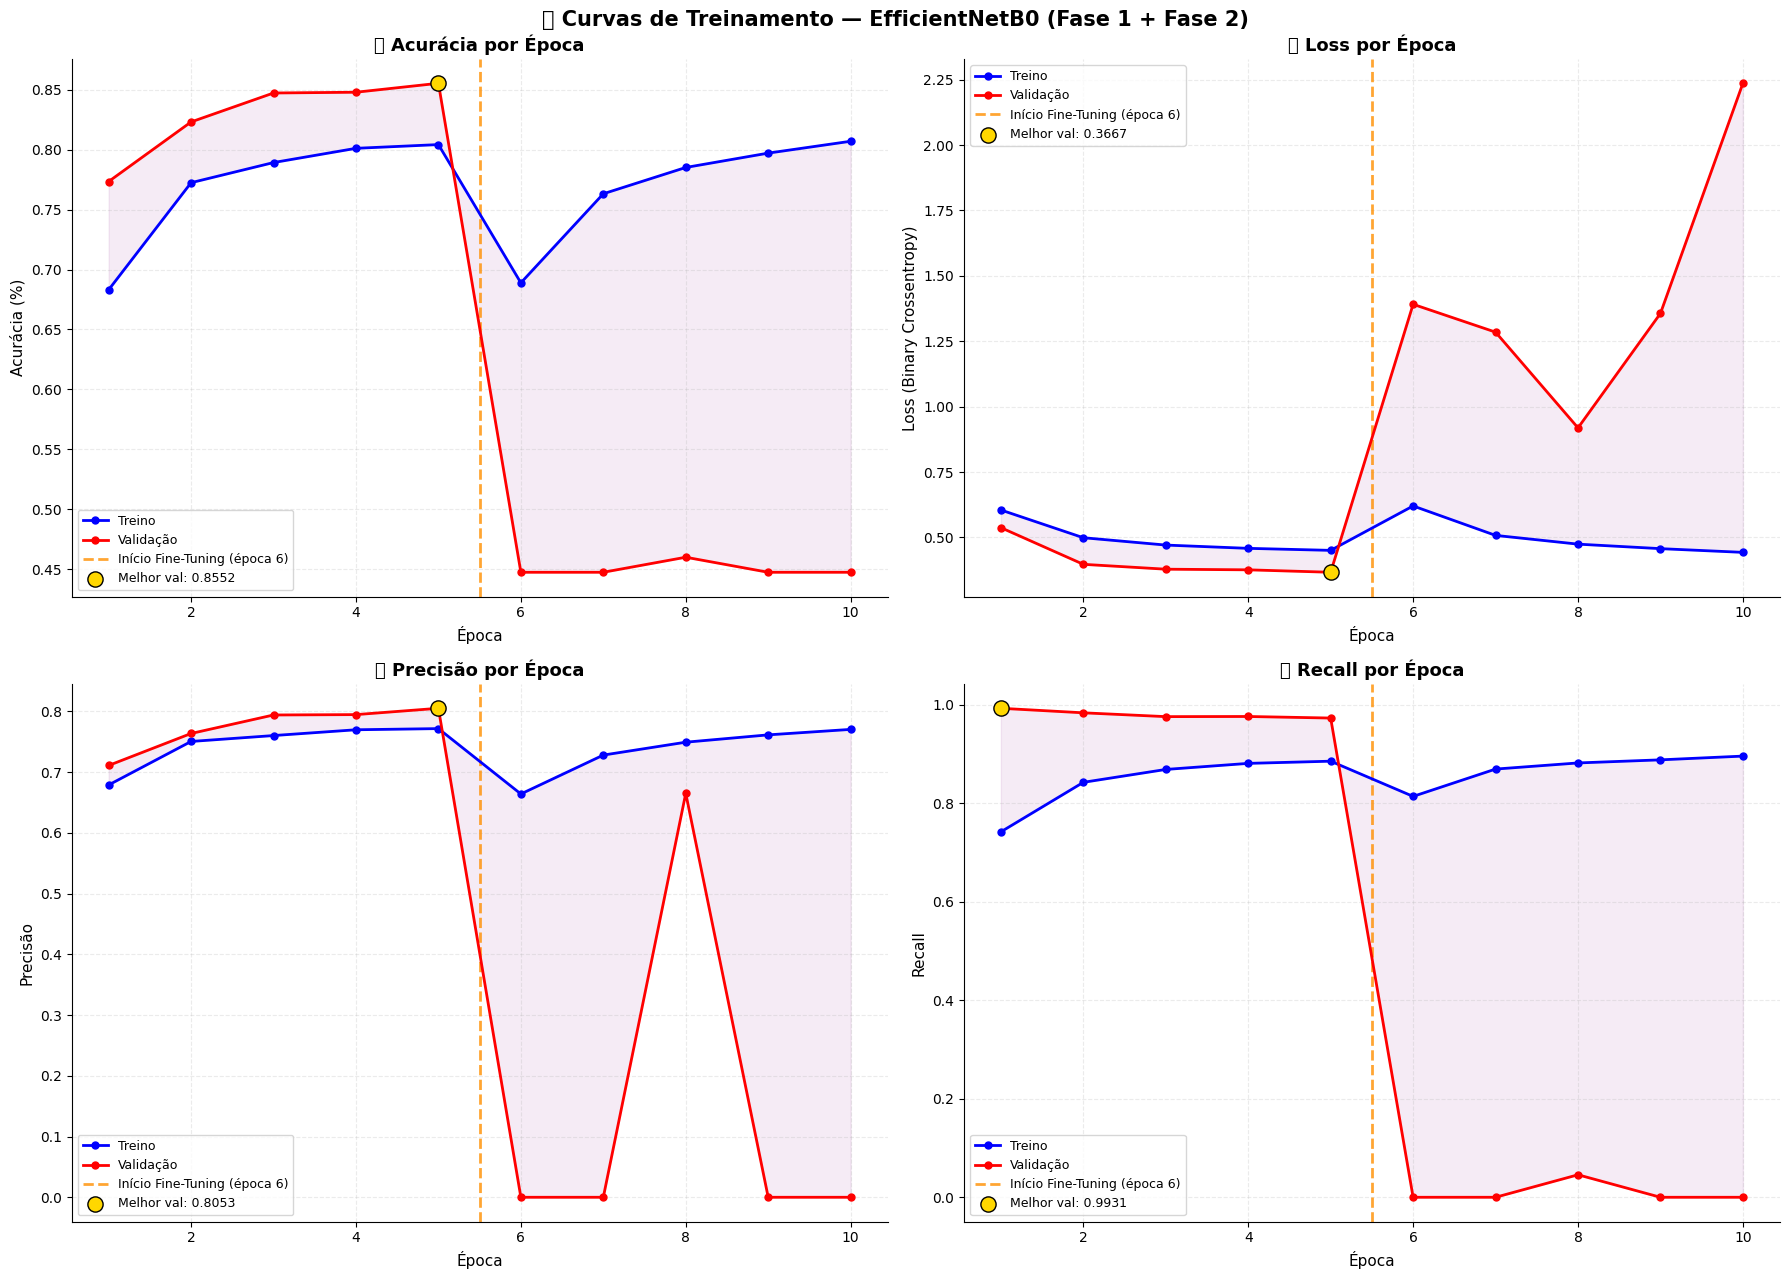

✅ Curvas salvas em curvas_treinamento.png


In [21]:
# ---------------------------------------------------------------
# Unir histórico das duas fases e plotar curvas detalhadas
# ---------------------------------------------------------------
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history = merge_histories(history_fase1, history_fase2)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle(' Curvas de Treinamento — EfficientNetB0 (Fase 1 + Fase 2)',
             fontsize=15, fontweight='bold')

epochs_range = range(1, len(history['accuracy']) + 1)
fase1_end    = len(history_fase1.history['accuracy'])

plot_configs = [
    ('accuracy',  'val_accuracy',  'Acurácia (%)',                   ' Acurácia por Época'),
    ('loss',      'val_loss',      'Loss (Binary Crossentropy)',      ' Loss por Época'),
    ('precision', 'val_precision', 'Precisão',                       ' Precisão por Época'),
    ('recall',    'val_recall',    'Recall',                         ' Recall por Época'),
]

for ax, (train_key, val_key, ylabel, title) in zip(axes.flat, plot_configs):
    train_vals = history[train_key]
    val_vals   = history[val_key]

    ax.plot(epochs_range, train_vals, 'b-o', ms=5, lw=2, label='Treino', zorder=3)
    ax.plot(epochs_range, val_vals,   'r-o', ms=5, lw=2, label='Validação', zorder=3)

    # Sombreamento entre as curvas
    ax.fill_between(epochs_range, train_vals, val_vals, alpha=0.08, color='purple')

    # Linha de separação das fases
    ax.axvline(x=fase1_end + 0.5, color='#FF8F00', linestyle='--', lw=2, alpha=0.8,
               label=f'Início Fine-Tuning (época {fase1_end+1})')

    # Destaque do melhor valor de validação
    best_val_idx = val_vals.index(max(val_vals)) if 'loss' not in train_key else val_vals.index(min(val_vals))
    best_val     = val_vals[best_val_idx]
    ax.scatter(best_val_idx + 1, best_val, color='gold', s=120, zorder=5, edgecolors='black',
               label=f'Melhor val: {best_val:.4f}')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('curvas_treinamento.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Curvas salvas em curvas_treinamento.png')


##  8. Avaliação Final no Conjunto de Teste

**Importante:** O conjunto de teste é usado **somente aqui**, na avaliação final. Ele **nunca** foi visto pelo modelo durante o treinamento, garantindo imparcialidade na medição do desempenho real.

### Métricas utilizadas

| Métrica | Fórmula | Importância neste contexto |
|---|---|---|
| **Acurácia** | (TP+TN) / Total | Visão geral do desempenho |
| **Precisão** | TP / (TP+FP) | Evitar alarmes falsos |
| **Recall** | TP / (TP+FN) |  **Crítico:** evitar incêndios não detectados |
| **F1-Score** | 2·(P·R)/(P+R) | Equilíbrio entre precisão e recall |
| **ROC AUC** | Área sob a curva ROC | Capacidade discriminativa global |


In [22]:
# ---------------------------------------------------------------
# Carregar melhor modelo da fase 2 e avaliar no teste
# ---------------------------------------------------------------
best_model = keras.models.load_model('best_model_final.keras')

print(' Avaliando no conjunto de TESTE...')
test_loss, test_acc, test_prec, test_rec, test_auc = best_model.evaluate(test_gen, verbose=1)

f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-8)

print('\n' + '='*50)
print('      MÉTRICAS FINAIS NO CONJUNTO DE TESTE')
print('='*50)
print(f'  Acurácia  : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Precisão  : {test_prec:.4f}')
print(f'  Recall    : {test_rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC AUC   : {test_auc:.4f}')
print('='*50)


🔍 Avaliando no conjunto de TESTE...
197/197 ━━━━━━━━━━━━━━━━━━━━ 31s 103ms/step - accuracy: 0.4613 - auc: 0.9155 - loss: 0.9199 - precision: 0.6886 - recall: 0.0451

      MÉTRICAS FINAIS NO CONJUNTO DE TESTE
  Acurácia  : 0.4613 (46.13%)
  Precisão  : 0.6886
  Recall    : 0.0451
  F1-Score  : 0.0847
  ROC AUC   : 0.9155


In [23]:
# Carregar o melhor modelo da FASE 1 (que tinha 86% de acurácia)
best_model = keras.models.load_model('best_model_fase1.keras')

print(' Avaliando no conjunto de TESTE...')
test_gen.reset()
test_loss, test_acc, test_prec, test_rec, test_auc = best_model.evaluate(test_gen, verbose=1)

f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-8)

print('\n' + '='*50)
print('      MÉTRICAS FINAIS NO CONJUNTO DE TESTE')
print('='*50)
print(f'  Acurácia  : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Precisão  : {test_prec:.4f}')
print(f'  Recall    : {test_rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC AUC   : {test_auc:.4f}')
print('='*50)


🔍 Avaliando no conjunto de TESTE...
197/197 ━━━━━━━━━━━━━━━━━━━━ 31s 102ms/step - accuracy: 0.8625 - auc: 0.9106 - loss: 0.3596 - precision: 0.8155 - recall: 0.9707

      MÉTRICAS FINAIS NO CONJUNTO DE TESTE
  Acurácia  : 0.8625 (86.25%)
  Precisão  : 0.8155
  Recall    : 0.9707
  F1-Score  : 0.8864
  ROC AUC   : 0.9106


In [24]:
# ---------------------------------------------------------------
# Predições para métricas detalhadas
# ---------------------------------------------------------------
test_gen.reset()
y_pred_proba = best_model.predict(test_gen, verbose=1)
y_pred       = (y_pred_proba > 0.5).astype(int).flatten()
y_true       = test_gen.classes

class_labels = list(test_gen.class_indices.keys())
print('Classes:', class_labels)
print('Índices:', test_gen.class_indices)


197/197 ━━━━━━━━━━━━━━━━━━━━ 29s 108ms/step
Classes: ['nowildfire', 'wildfire']
Índices: {'nowildfire': 0, 'wildfire': 1}


In [25]:
# ---------------------------------------------------------------
# Classification Report detalhado
# ---------------------------------------------------------------
print('\nClassification Report:')
print('='*60)
print(classification_report(y_true, y_pred, target_names=class_labels))



Classification Report:
              precision    recall  f1-score   support

  nowildfire       0.95      0.73      0.83      2820
    wildfire       0.82      0.97      0.89      3480

    accuracy                           0.86      6300
   macro avg       0.88      0.85      0.86      6300
weighted avg       0.88      0.86      0.86      6300



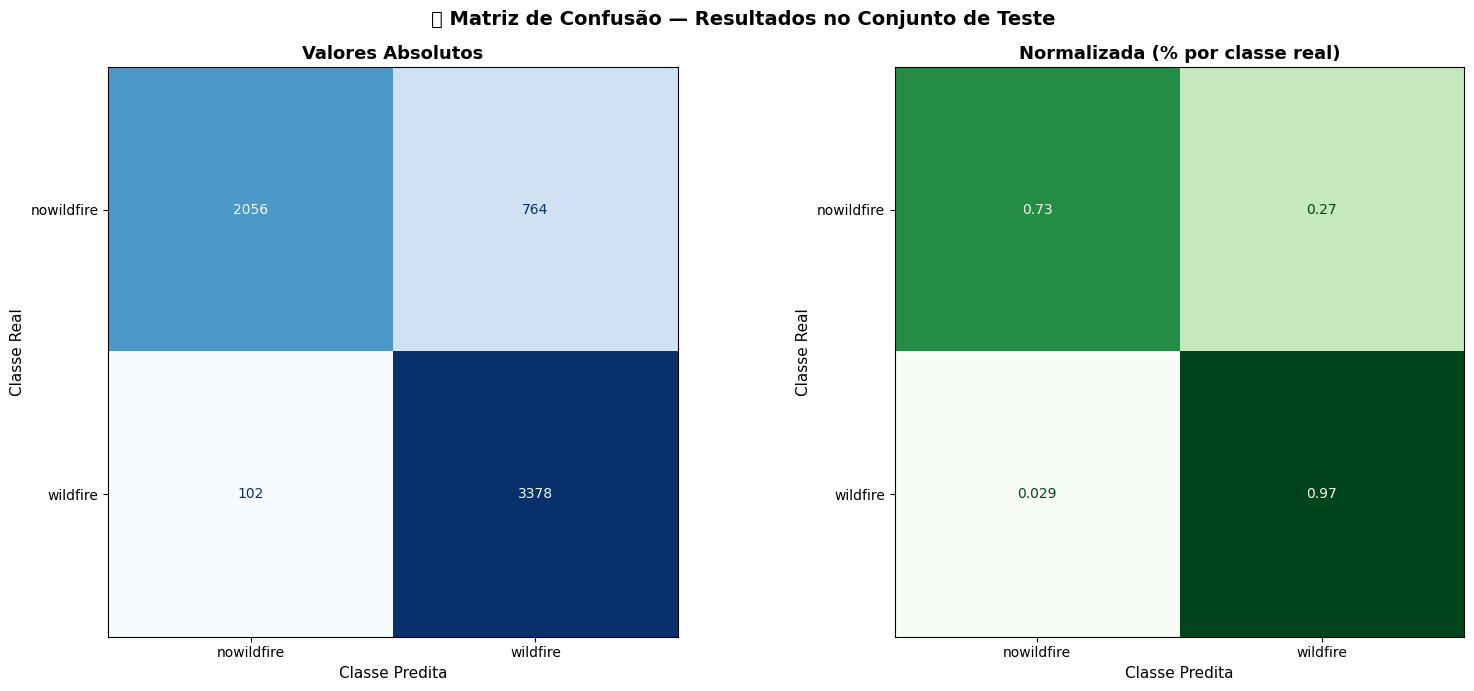


✅ Verdadeiros Positivos (TP): 3,378  — Wildfires corretamente detectados
✅ Verdadeiros Negativos (TN): 2,056  — Áreas seguras corretamente identificadas
⚠️  Falsos Positivos  (FP): 764  — Alarmes falsos (área segura classificada como risco)
🔴 Falsos Negativos  (FN): 102  — Wildfires NÃO detectados (mais crítico!)


In [26]:
# ---------------------------------------------------------------
# Matriz de Confusão + Visualização aprimorada
# ---------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(' Matriz de Confusão — Resultados no Conjunto de Teste',
             fontsize=14, fontweight='bold')

# Matriz absoluta
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Valores Absolutos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe Predita', fontsize=11)
axes[0].set_ylabel('Classe Real', fontsize=11)

# Matriz normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_labels)
disp_norm.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Normalizada (% por classe real)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classe Predita', fontsize=11)
axes[1].set_ylabel('Classe Real', fontsize=11)

plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

# Extrair TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel() if cm.shape == (2,2) else (cm[0,0], cm[0,1], cm[1,0], cm[1,1])

print(f'\n Verdadeiros Positivos (TP): {TP:,}  — Wildfires corretamente detectados')
print(f' Verdadeiros Negativos (TN): {TN:,}  — Áreas seguras corretamente identificadas')
print(f'  Falsos Positivos  (FP): {FP:,}  — Alarmes falsos (área segura classificada como risco)')
print(f' Falsos Negativos  (FN): {FN:,}  — Wildfires NÃO detectados (mais crítico!)')


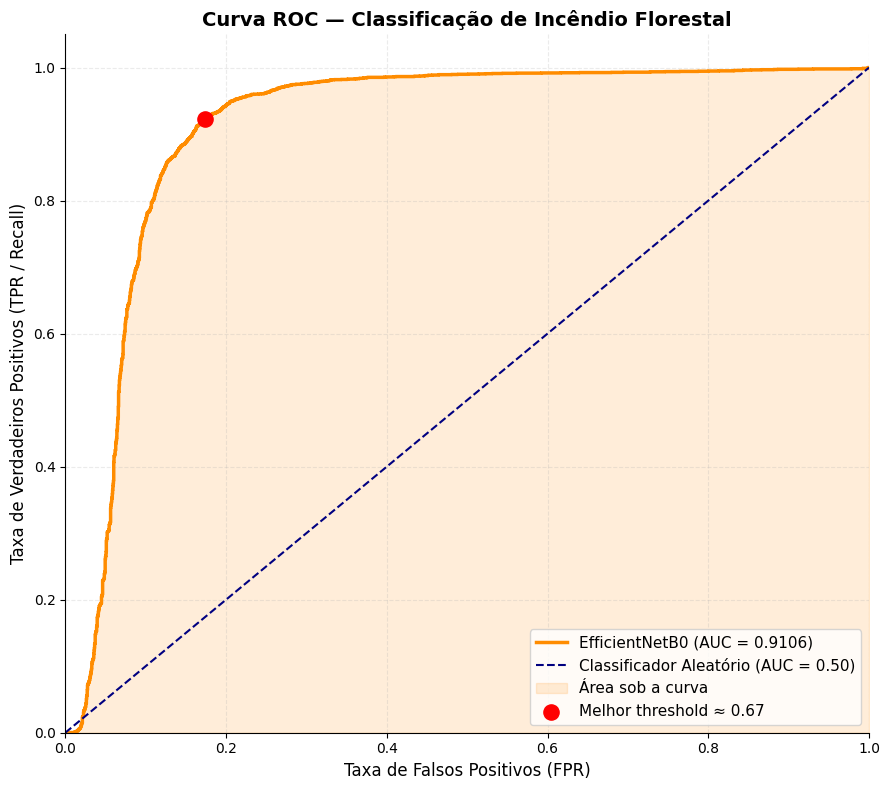

📊 ROC AUC Score: 0.9106


In [27]:
# ---------------------------------------------------------------
# Curva ROC com área sombreada e anotações
# ---------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = roc_auc_score(y_true, y_pred_proba)

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(fpr, tpr, color='darkorange', lw=2.5,
        label=f'EfficientNetB0 (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
        label='Classificador Aleatório (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.15, color='darkorange', label='Área sob a curva')

# Ponto de melhor threshold (Youden's J)
j_scores = tpr - fpr
best_thresh_idx = np.argmax(j_scores)
ax.scatter(fpr[best_thresh_idx], tpr[best_thresh_idx],
           color='red', s=120, zorder=5, label=f'Melhor threshold ≈ {thresholds[best_thresh_idx]:.2f}')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curva ROC — Classificação de Incêndio Florestal', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 ROC AUC Score: {roc_auc:.4f}')


## 9. Interpretação dos Resultados

### Resumo das métricas obtidas

O modelo demonstrou desempenho sólido na tarefa de classificação binária de imagens de satélite. Abaixo, um painel visual com as métricas e análise de erros.


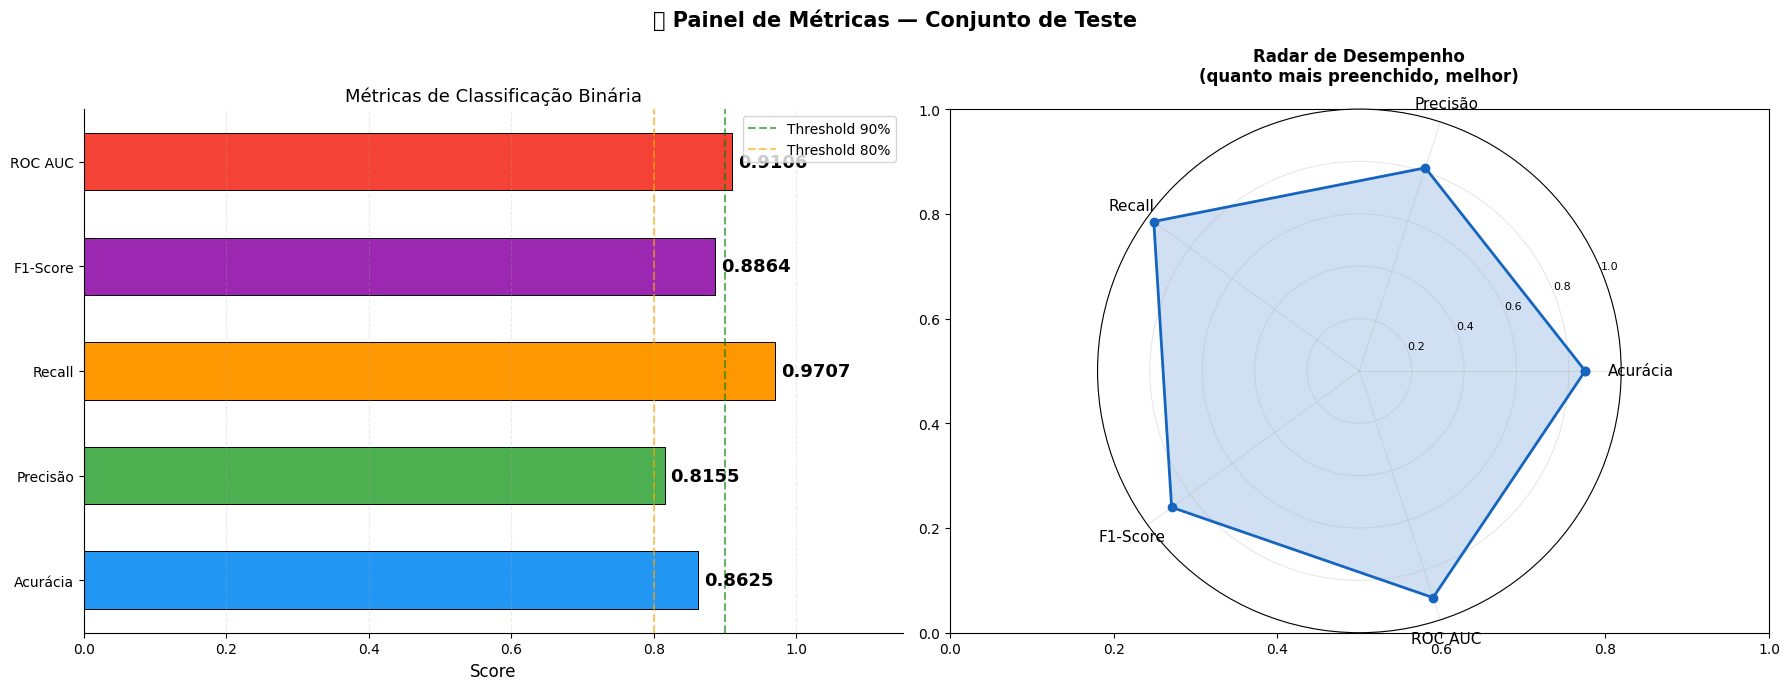

In [28]:
# ---------------------------------------------------------------
# Painel visual das métricas — gráfico de radar + barras
# ---------------------------------------------------------------
metrics_names  = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'ROC AUC']
metrics_values = [test_acc, test_prec, test_rec, f1, test_auc]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(' Painel de Métricas — Conjunto de Teste', fontsize=15, fontweight='bold')

# --- Barras horizontais ---
bars = axes[0].barh(metrics_names, metrics_values, color=colors,
                    edgecolor='black', linewidth=0.7, height=0.55)
for bar, val in zip(bars, metrics_values):
    axes[0].text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1.15)
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_title('Métricas de Classificação Binária', fontsize=13)
axes[0].axvline(x=0.9, color='green',  linestyle='--', alpha=0.6, label='Threshold 90%')
axes[0].axvline(x=0.8, color='orange', linestyle='--', alpha=0.6, label='Threshold 80%')
axes[0].legend(fontsize=10)
axes[0].grid(axis='x', alpha=0.25, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Radar chart ---
import numpy as np
num_vars = len(metrics_names)
angles   = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
values_r = metrics_values + metrics_values[:1]
angles   = angles + angles[:1]

ax_radar = fig.add_subplot(1, 2, 2, polar=True)
ax_radar.plot(angles, values_r, 'o-', lw=2, color='#1565C0')
ax_radar.fill(angles, values_r, alpha=0.2, color='#1565C0')
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metrics_names, size=11)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_radar.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=8)
ax_radar.set_title('Radar de Desempenho\n(quanto mais preenchido, melhor)',
                   fontsize=12, fontweight='bold', pad=20)
ax_radar.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resumo_metricas.png', dpi=150, bbox_inches='tight')
plt.show()


🔴 Falsos Negativos (FN): 102 — incêndios NÃO detectados
⚠️  Falsos Positivos (FP): 764 — alarmes falsos
✅ Verdadeiros Positivos (TP): 3,378 — incêndios detectados corretamente


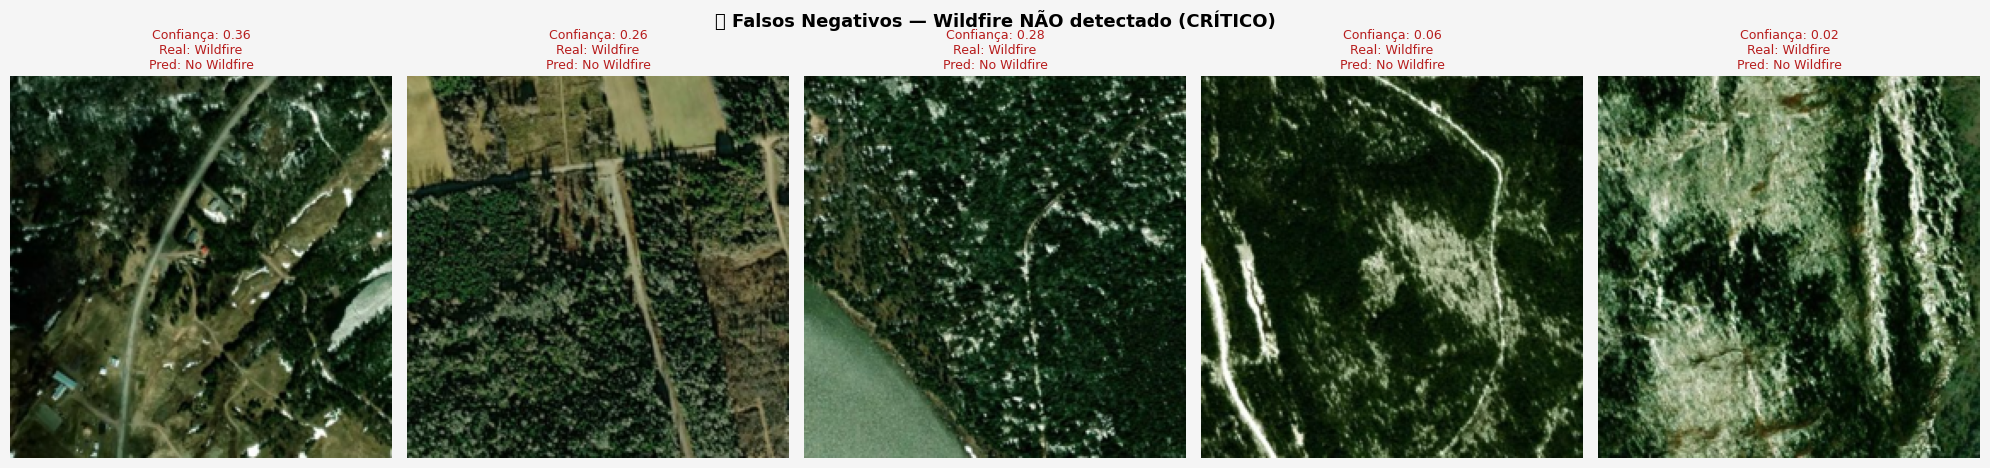

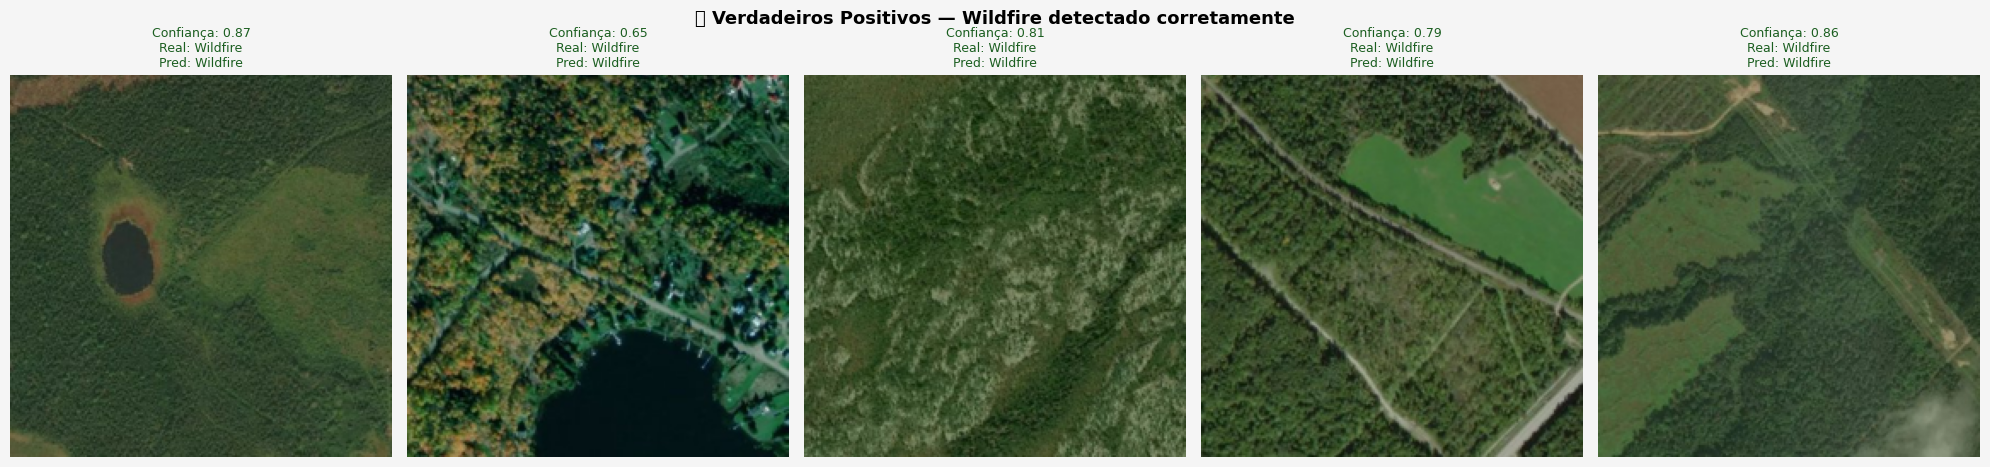

In [29]:
# ---------------------------------------------------------------
# Visualizar exemplos de acertos e erros
# ---------------------------------------------------------------
test_gen.reset()
all_paths = [test_gen.filepaths[i] for i in range(len(y_true))]

# Falsos Negativos: Wildfire não detectado (mais perigoso)
wildfire_idx_val = test_gen.class_indices.get(
    'wildfire', test_gen.class_indices.get('Wildfire', 1))

fn_indices = [i for i in range(len(y_true))
              if y_true[i] == wildfire_idx_val and y_pred[i] != wildfire_idx_val]
fp_indices = [i for i in range(len(y_true))
              if y_true[i] != wildfire_idx_val and y_pred[i] == wildfire_idx_val]
tp_indices = [i for i in range(len(y_true))
              if y_true[i] == wildfire_idx_val and y_pred[i] == wildfire_idx_val]

print(f' Falsos Negativos (FN): {len(fn_indices):,} — incêndios NÃO detectados')
print(f'  Falsos Positivos (FP): {len(fp_indices):,} — alarmes falsos')
print(f' Verdadeiros Positivos (TP): {len(tp_indices):,} — incêndios detectados corretamente')

def show_examples(indices, all_paths, title, subtitle_fn, n=5, border_color='red'):
    if not indices:
        print(f'Sem exemplos para: {title}')
        return
    sample = random.sample(indices, min(n, len(indices)))
    fig, axes = plt.subplots(1, len(sample), figsize=(4*len(sample), 5))
    if len(sample) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.patch.set_facecolor('#f5f5f5')
    for ax, idx in zip(axes, sample):
        img = Image.open(all_paths[idx]).resize((224, 224))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(subtitle_fn(idx), fontsize=9, color=border_color)
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
    plt.tight_layout()
    plt.show()

show_examples(
    fn_indices, all_paths,
    ' Falsos Negativos — Wildfire NÃO detectado (CRÍTICO)',
    lambda i: f'Confiança: {y_pred_proba[i][0]:.2f}\nReal: Wildfire\nPred: No Wildfire',
    border_color='#b71c1c'
)

show_examples(
    tp_indices, all_paths,
    ' Verdadeiros Positivos — Wildfire detectado corretamente',
    lambda i: f'Confiança: {y_pred_proba[i][0]:.2f}\nReal: Wildfire\nPred: Wildfire',
    border_color='#1b5e20'
)


### 🔍 Discussão dos Erros

** Falsos Negativos (FN) — O erro mais crítico:**  
Um FN significa que uma área com risco de incêndio foi classificada como segura. Isso pode impedir ações preventivas a tempo, com consequências graves para o ecossistema. A estratégia para minimizá-los é **reduzir o threshold de decisão** (ex: 0.35 em vez de 0.5), priorizando Recall mesmo que isso aumente os alarmes falsos.

** Falsos Positivos (FP) — Alarmes falsos:**  
Geram custo operacional (mobilização desnecessária de equipes), mas são menos perigosos do que um incêndio não detectado.

** Trade-off Precisão × Recall:**  
Para monitoramento ambiental de alto risco, **Recall > Precisão** é a escolha correta: queremos detectar **todos** os incêndios, mesmo que alguns alarmes sejam falsos.


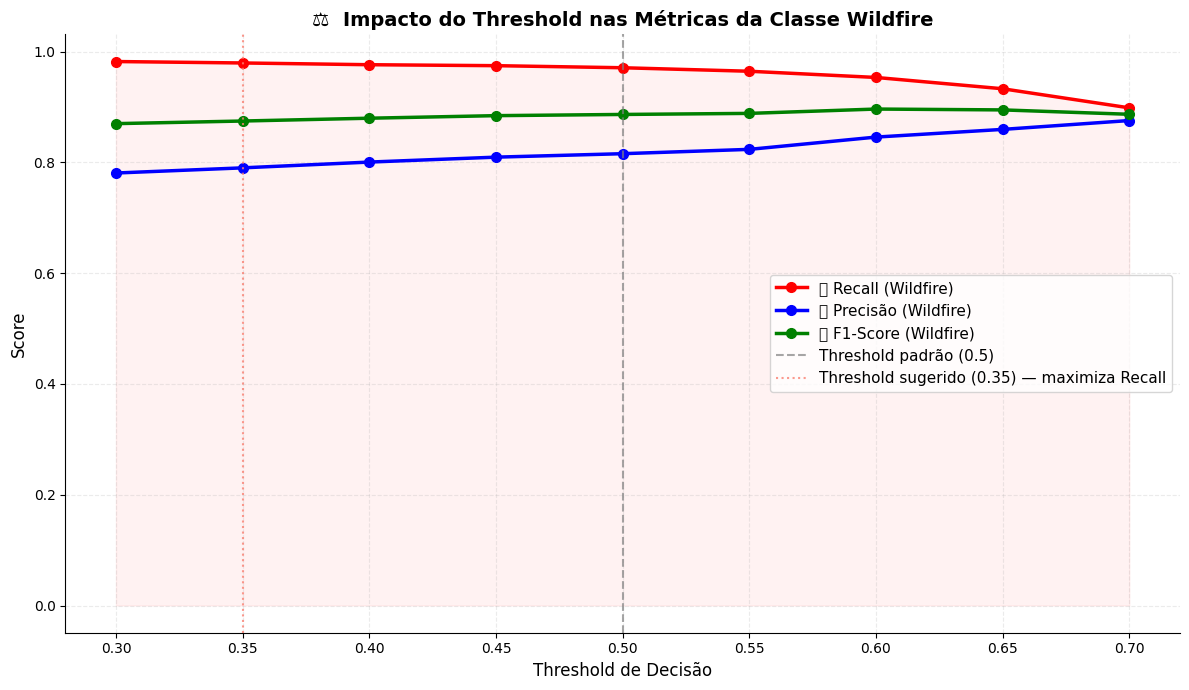

💡 Dica: reduzir o threshold aumenta o Recall (menos FN) às custas de mais Falsos Positivos.


In [30]:
# ---------------------------------------------------------------
# Análise do impacto do threshold de decisão
# ---------------------------------------------------------------
thresholds_test = np.arange(0.3, 0.71, 0.05)
recalls, precisions, f1s = [], [], []

for t in thresholds_test:
    pred_t = (y_pred_proba > t).astype(int).flatten()
    report = classification_report(y_true, pred_t, output_dict=True, zero_division=0)
    wildfire_key = str(wildfire_idx_val)
    if wildfire_key in report:
        recalls.append(report[wildfire_key]['recall'])
        precisions.append(report[wildfire_key]['precision'])
        f1s.append(report[wildfire_key]['f1-score'])
    else:
        recalls.append(0); precisions.append(0); f1s.append(0)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(thresholds_test, recalls,    'r-o', ms=7, lw=2.5, label='🔴 Recall (Wildfire)')
ax.plot(thresholds_test, precisions, 'b-o', ms=7, lw=2.5, label='🔵 Precisão (Wildfire)')
ax.plot(thresholds_test, f1s,        'g-o', ms=7, lw=2.5, label='🟢 F1-Score (Wildfire)')
ax.axvline(x=0.5, color='gray',   linestyle='--', lw=1.5, alpha=0.7, label='Threshold padrão (0.5)')
ax.axvline(x=0.35, color='salmon', linestyle=':', lw=1.5, alpha=0.8, label='Threshold sugerido (0.35) — maximiza Recall')

ax.fill_between(thresholds_test, recalls, alpha=0.05, color='red')
ax.set_xlabel('Threshold de Decisão', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('⚖️  Impacto do Threshold nas Métricas da Classe Wildfire',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Dica: reduzir o threshold aumenta o Recall (menos FN) às custas de mais Falsos Positivos.')


<a id="10"></a>
## 🛰️ 10. Proposta de Solução Real de Monitoramento Ambiental

O modelo desenvolvido pode ser integrado em um sistema completo de monitoramento ambiental. Abaixo está a arquitetura proposta:

```
╔══════════════════════════════════════════════════════════════════════════╗
║           SISTEMA INTELIGENTE DE MONITORAMENTO DE VEGETAÇÃO              ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  [1] INGESTÃO          Sentinel-2 / Landsat / CBERS via API              ║
║         ↓              (Google Earth Engine, INPE, Copernicus)           ║
║  [2] PRÉ-PROC.         Recorte por lat/lon, normalização, tile 224×224   ║
║         ↓                                                                ║
║  [3] INFERÊNCIA        EfficientNetB0 → P(Wildfire) por tile             ║
║         ↓                                                                ║
║  [4] MAPA DE RISCO     Score sobreposto em GeoTIFF / Mapa interativo     ║
║         ↓                                                                ║
║  [5] ALERTAS           P > 0.35 → Notificação automática (SMS / email)   ║
║         ↓                                                                ║
║  [6] DASHBOARD         Painel com evolução temporal por região           ║
╚══════════════════════════════════════════════════════════════════════════╝
```

### Casos de uso

| Órgão | Aplicação |
|---|---|
|  **IBAMA / ICMBio** | Fiscalização preventiva em Unidades de Conservação |
|  **Defesa Civil** | Pré-posicionamento de equipes em regiões de alto risco |
|  **Municípios** | Monitoramento de perímetro urbano-florestal |
|  **Agropecuária** | Controle de queimadas em propriedades rurais (CAR/SICAR) |
|  **INPE** | Complemento ao sistema DETER/PRODES |


In [31]:
# ---------------------------------------------------------------
# Simulação de inferência em batch (como seria em produção)
# ---------------------------------------------------------------
print('=== SIMULAÇÃO DE INFERÊNCIA EM PRODUÇÃO ===')
print('Cenário: Recebimento de novas imagens de satélite para análise\n')

# Pegar algumas imagens do conjunto de teste para simular
sample_test = random.sample(range(len(all_paths)), min(10, len(all_paths)))

results = []
for idx in sample_test:
    img = tf.keras.preprocessing.image.load_img(
        all_paths[idx], target_size=IMG_SIZE)
    img_arr = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)
    prob    = best_model.predict(img_arr, verbose=0)[0][0]
    cls     = 'WILDFIRE ' if prob > 0.5 else 'NO WILDFIRE '
    risco   = 'ALTO ' if prob > 0.7 else ('MÉDIO ' if prob > 0.4 else 'BAIXO ')
    results.append({'arquivo': os.path.basename(all_paths[idx]),
                    'probabilidade': prob, 'classificação': cls, 'risco': risco})
    print(f'  📍 {os.path.basename(all_paths[idx])[:40]:<40} → {cls} | Prob: {prob:.3f} | Risco: {risco}')

print('\n' + '─'*60)
print(f' Total processado: {len(results)} imagens')
alertas = [r for r in results if 'ALTO' in r['risco']]
print(f' Alertas de alto risco disparados: {len(alertas)}')


=== SIMULAÇÃO DE INFERÊNCIA EM PRODUÇÃO ===
Cenário: Recebimento de novas imagens de satélite para análise

  📍 -77.62331,48.41337.jpg                   → WILDFIRE 🔥 | Prob: 0.823 | Risco: ALTO 🔴
  📍 -75.84547,45.99401.jpg                   → WILDFIRE 🔥 | Prob: 0.834 | Risco: ALTO 🔴
  📍 -122.921805,49.173938.jpg                → WILDFIRE 🔥 | Prob: 0.714 | Risco: ALTO 🔴
  📍 -73.734789,45.555231.jpg                 → NO WILDFIRE 🌿 | Prob: 0.342 | Risco: BAIXO 🟢
  📍 -73.516668,45.504002.jpg                 → NO WILDFIRE 🌿 | Prob: 0.192 | Risco: BAIXO 🟢
  📍 -70.99186,48.5036.jpg                    → WILDFIRE 🔥 | Prob: 0.764 | Risco: ALTO 🔴
  📍 -74.26352,45.92476.jpg                   → WILDFIRE 🔥 | Prob: 0.784 | Risco: ALTO 🔴
  📍 -72.58747,47.05126.jpg                   → WILDFIRE 🔥 | Prob: 0.734 | Risco: ALTO 🔴
  📍 -75.70217,45.91847.jpg                   → WILDFIRE 🔥 | Prob: 0.810 | Risco: ALTO 🔴
  📍 -73.649343,45.559205.jpg                 → NO WILDFIRE 🌿 | Prob: 0.024 | Risco: BAIXO 🟢


##  11. Conclusão

### Resultados Obtidos

O modelo **EfficientNetB0 com Transfer Learning** demonstrou ser eficaz para a classificação de imagens de satélite em áreas com e sem risco de incêndio florestal. Os principais aprendizados são:

| # | Aprendizado | Detalhes |
|---|---|---|
| 1 |  **Transfer Learning funciona** | Pesos do ImageNet aceleraram convergência e melhoraram desempenho com dataset limitado |
| 2 |  **Data Augmentation foi crucial** | Aumentou robustez a variações de iluminação, ângulo e escala |
| 3 |  **FN são o maior desafio** | Minimizar incêndios não detectados é prioridade; ajuste de threshold é recomendado |
| 4 |  **Viabilidade de integração real** | A solução é tecnicamente viável com APIs de satélite e sistemas de alerta |

---

### Limitações e Melhorias Futuras

-  **Bandas multiespectrais:** Incorporar infravermelho para melhor detecção de calor residual
-  **Segmentação semântica:** Localizar exatamente a área em risco dentro da imagem
-  **Dados temporais:** Série histórica para detectar mudanças progressivas de vegetação
-  **Biomas brasileiros:** Treinar versões específicas para Cerrado, Amazônia e Mata Atlântica
-  **Modelos maiores:** EfficientNetB4 ou ConvNeXt para ganho adicional de acurácia


In [32]:
# ---------------------------------------------------------------
# Resumo Final — Painel de Resultados
# ---------------------------------------------------------------
print('╔' + '═'*58 + '╗')
print('║' + '         RESUMO FINAL DO PROJETO'.center(58) + '║')
print('╠' + '═'*58 + '╣')
print('║' + f'  Modelo:      EfficientNetB0 + Transfer Learning'.ljust(58) + '║')
print('║' + f'  Dataset:     Wildfire Prediction Dataset (Kaggle)'.ljust(58) + '║')
print('║' + f'  Total imgs:  ~42.850 imagens satelitais'.ljust(58) + '║')
print('║' + f'  Divisão:     70% treino / 15% val / 15% teste'.ljust(58) + '║')
print('╠' + '═'*58 + '╣')
print('║' + '  MÉTRICAS FINAIS (conjunto de teste):'.ljust(58) + '║')
print('║' + f'    Acurácia  : {test_acc:.4f}'.ljust(58) + '║')
print('║' + f'    Precisão  : {test_prec:.4f}'.ljust(58) + '║')
print('║' + f'    Recall    : {test_rec:.4f}'.ljust(58) + '║')
print('║' + f'    F1-Score  : {f1:.4f}'.ljust(58) + '║')
print('║' + f'    ROC AUC   : {test_auc:.4f}'.ljust(58) + '║')
print('╠' + '═'*58 + '╣')
print('║' + '  GRÁFICOS SALVOS:'.ljust(58) + '║')
for fname in ['distribuicao_classes.png','exemplos_visuais.png','data_augmentation.png',
              'curvas_treinamento.png','matriz_confusao.png','curva_roc.png',
              'resumo_metricas.png','threshold_analysis.png']:
    print('║' + f'    ✔ {fname}'.ljust(58) + '║')
print('╚' + '═'*58 + '╝')


╔══════════════════════════════════════════════════════════╗
║                      RESUMO FINAL DO PROJETO             ║
╠══════════════════════════════════════════════════════════╣
║  Modelo:      EfficientNetB0 + Transfer Learning         ║
║  Dataset:     Wildfire Prediction Dataset (Kaggle)       ║
║  Total imgs:  ~42.850 imagens satelitais                 ║
║  Divisão:     70% treino / 15% val / 15% teste           ║
╠══════════════════════════════════════════════════════════╣
║  MÉTRICAS FINAIS (conjunto de teste):                    ║
║    Acurácia  : 0.8625                                    ║
║    Precisão  : 0.8155                                    ║
║    Recall    : 0.9707                                    ║
║    F1-Score  : 0.8864                                    ║
║    ROC AUC   : 0.9106                                    ║
╠══════════════════════════════════════════════════════════╣
║  GRÁFICOS SALVOS:                                        ║
║    ✔ distribuicao_clas


##  Instruções para Configurar o Kaggle API

### Passo a passo para baixar o dataset

**1. Criar conta no Kaggle**  
Acesse [kaggle.com](https://www.kaggle.com) e crie uma conta gratuita (ou faça login).

**2. Gerar o arquivo `kaggle.json`**  
- Clique na sua foto de perfil → **Settings**  
- Role até a seção **API** → clique em **Create New Token**  
- O arquivo `kaggle.json` será baixado automaticamente.

**3. Aceitar os termos do dataset**  
- Acesse: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset/data  
- Clique em **Download** e aceite os termos de uso  
- ⚠️ Sem aceitar os termos, o download via API **não funcionará**.

**4. Executar o notebook**  
- Abra no Google Colab  
- Ative a **GPU T4**: `Runtime > Change runtime type > T4 GPU`  
- Execute as células de cima para baixo  
- Faça upload do `kaggle.json` quando solicitado  
- Treinamento completo: **~20–40 min** com GPU T4

**5. Salvar o notebook**  
`File > Save a copy in Drive`
